In [32]:

from DATA.stock_invest_function import *

import pymysql
import pandas as pd
from typing import Dict, Optional
from typing import Tuple

def fetch_roe_roa_from_db(db_info: Dict,
                          ticker: str,
                          indicator: str,
                          table_name: str = "korea_fs_data_roe_roa") -> pd.DataFrame:
    """
    investar.korea_fs_data_roe_roa 에서
    특정 ticker + indicator 의 시계열 데이터를 가져오는 함수.
    """
    # db / database 둘 다 허용
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, ticker, indicator, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = %s
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, indicator])
    finally:
        conn.close()

    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

    return df


def fetch_required_return_quarterly_avg(db_info: Dict,
                                        ticker: str,
                                        table_name: str = "korea_required_return_result") -> pd.DataFrame:
    """
    특정 ticker 의 required_return 을 불러와
    분기별 평균 required_return 을 계산.
    """
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, ticker, indicator, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = 'Required_Return'
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return df

    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    quarterly = (
        df
        .set_index("date")
        .groupby([pd.Grouper(freq="Q"), "ticker"])["value"]
        .mean()
        .reset_index()
        .rename(columns={"value": "required_return_q_avg"})
    )

    return quarterly

from typing import Dict, Optional


def fetch_latest_equity(db_info: Dict,
                        ticker: str,
                        table_name: str = "korea_fs_data_roe_roa") -> Optional[float]:
    """
    특정 ticker의 '자본총계' indicator의 가장 최근 value 값을 반환하는 함수.
    값이 없거나 존재하지 않으면 None 반환.
    """

    # db 또는 database 키 모두 지원
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = '자본총계'
            ORDER BY date DESC
            LIMIT 1
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return None

    # value 숫자 변환
    value = pd.to_numeric(df.loc[0, "value"], errors="coerce")

    return value

import pymysql
import pandas as pd
from typing import Dict


def fetch_yearly_avg_payout_ratio(db_info: Dict,
                                  ticker: str,
                                  table_name: str = "korea_fs_data_roe_roa") -> pd.DataFrame:
    """
    특정 ticker의 payout_ratio 값을 DB에서 불러와
    절대값으로 변환한 뒤,
    연간 평균 payout_ratio를 계산하여 반환.

    반환 DataFrame:
        year | ticker | payout_ratio_yearly_avg
    """
    # db 또는 database 키 모두 지원
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = 'payout_ratio'
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return df

    # 날짜 변환
    df["date"] = pd.to_datetime(df["date"])

    # 숫자 변환
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # 절대값 처리
    df["value"] = df["value"].abs()

    # 연도 정보 생성
    df["year"] = df["date"].dt.year

    # 연간 평균 계산
    yearly_avg = (
        df.groupby("year")["value"]
        .mean()
        .reset_index()
        .rename(columns={"value": "payout_ratio_yearly_avg"})
    )

    # ticker 추가
    yearly_avg["ticker"] = ticker

    # 순서 정리
    yearly_avg = yearly_avg[["year", "ticker", "payout_ratio_yearly_avg"]]

    return yearly_avg


def get_required_return_pivot(db_info, ticker,
                              table_name="korea_required_return_result"):

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4",
        cursorclass=pymysql.cursors.DictCursor,
    )

    try:
        sql = f"""
            SELECT date, indicator, value
            FROM {table_name}
            WHERE ticker = %s
        """
        df = pd.read_sql(sql, conn, params=(ticker,), parse_dates=["date"])

    finally:
        conn.close()

    print("[DEBUG] fetched rows:", df.shape)
    print("[DEBUG] df.dtypes:\n", df.dtypes)
    print("[DEBUG] df.head(5):\n", df.head(5))

    # NaN 개수 확인
    print("[DEBUG] NULL indicator count:", df["indicator"].isna().sum())
    print("[DEBUG] NULL date count:", df["date"].isna().sum())
    print("[DEBUG] NULL value count:", df["value"].isna().sum())

    # ----- 🔥 핵심 정리 과정 🔥 -----
    df["indicator"] = df["indicator"].astype(str).str.strip()

    # parse_dates에서 이미 datetime으로 파싱했으므로 다시 coerce 할 필요는 거의 없음
    # 문제 확인을 위해 일단 에러 나게 두는 것도 방법
    # df["date"] = pd.to_datetime(df["date"], errors="raise")

    # 여기서는 date만 dropna 해보고 indicator는 일단 두겠습니다
    df = df.dropna(subset=["date"])
    print("[DEBUG] after cleaning:", df.shape)

    print("[DEBUG] indicator unique (sample):", df["indicator"].unique()[:20])

    pivot_df = df.pivot_table(
        index="date",
        columns="indicator",
        values="value",
        aggfunc="mean"
    ).sort_index()

    return pivot_df



def residual_income_valuation(
    initial_book_value: float,
    current_roe: float,
    required_return: float,
    payout_ratio: float = 0.05,
    n_high_years: int = 3,
    n_fade_years: int = 7,
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model로 기업 가치를 계산.

    Parameters
    ----------
    initial_book_value : float
        t=0 시점의 기초 자기자본 (B0)
    current_roe : float
        현재 ROE (예: 0.30 = 30%)
    required_return : float
        요구수익률 re (예: 0.10727 = 10.727%), 할인율도 이 값 사용
    payout_ratio : float, default 0.05
        배당성향 (NI 중 배당 비율)
    n_high_years : int, default 3
        현재 ROE가 유지되는 기간 (년 수)
    n_fade_years : int, default 7
        ROE가 점진적으로 required_return 수준까지 떨어지는 기간 (년 수)

    Returns
    -------
    ri_df : pd.DataFrame
        연도별 Book Value, ROE, re, (ROE - re), NI, Residual Income,
        Dividend, Ending Book, Present Value of RI 등을 담은 표
    intrinsic_value : float
        Residual Income Model로 계산한 적정 가치 (B0 + PV(RI))
    """

    total_years = n_high_years + n_fade_years

    # 1) ROE 경로 생성
    # 1~n_high_years: current_roe 유지
    high_roe = np.full(n_high_years, current_roe)

    # 이후 n_fade_years 동안 current_roe -> required_return 선형하락
    # 예: [0.30, ..., 0.10727] 중 첫 번째를 버리고 7개만 사용
    fade_roe = np.linspace(current_roe, required_return, n_fade_years + 1)[1:]

    roe_path = np.concatenate([high_roe, fade_roe])

    # 2) 연도별 계산
    records = []
    B_t = float(initial_book_value)

    for year in range(1, total_years + 1):
        roe_t = float(roe_path[year - 1])
        re_t = float(required_return)

        # 당기순이익
        ni_t = B_t * roe_t

        # 배당
        div_t = ni_t * payout_ratio

        # Residual Income
        spread_t = roe_t - re_t      # (ROE - re)
        ri_t = B_t * spread_t        # RI_t = B_{t-1} * (ROE_t - re)

        # 기말 자기자본
        end_B = B_t + ni_t - div_t   # B_t + (1 - payout)*NI_t

        # 현재가치
        discount_factor = 1 / ((1 + re_t) ** year)
        pv_ri_t = ri_t * discount_factor

        records.append({
            "year": year,
            "begin_book": B_t,
            "roe": roe_t,
            "required_return": re_t,
            "spread_roe_minus_re": spread_t,
            "net_income": ni_t,
            "dividend": div_t,
            "residual_income": ri_t,
            "end_book": end_B,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri_t,
        })

        # 다음 해를 위해 갱신
        B_t = end_B

    ri_df = pd.DataFrame(records)

    # 3) 적정 가치 계산: V0 = B0 + Σ PV(RI_t)
    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value

def rim_constant_spread_with_payout(
    initial_book_value: float,
    required_return: float,
    spread: float = 0.06,
    payout_ratio: float = 0.05,
    horizon_years: int = 30,
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model with:
    - constant spread (ROE = re + spread)
    - payout ratio (<100%)
    - growing book value

    Parameters
    ----------
    initial_book_value : float
    required_return : float (e.g., 0.10)
    spread : float (e.g., 0.06)
    payout_ratio : float (e.g., 0.05 → 5%)
    horizon_years : int

    Returns
    -------
    ri_df : pd.DataFrame (detailed calculation sheet)
    intrinsic_value : float (V0 = B0 + Σ PV(RI_t))
    """

    B_t = float(initial_book_value)
    re = float(required_return)
    s = float(spread)
    payout = float(payout_ratio)

    roe = re + s

    records = []

    for t in range(1, horizon_years + 1):
        # 순이익
        ni = B_t * roe

        # 배당
        dividend = ni * payout

        # Residual Income
        ri = B_t * s

        # 할인
        discount_factor = 1 / ((1 + re) ** t)
        pv_ri = ri * discount_factor

        # 기말 자본
        end_book = B_t + ni - dividend

        records.append({
            "year": t,
            "begin_book": B_t,
            "roe": roe,
            "required_return": re,
            "spread_roe_minus_re": s,
            "net_income": ni,
            "dividend": dividend,
            "residual_income": ri,
            "end_book": end_book,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri,
        })

        B_t = end_book  # 다음 해로 업데이트

    ri_df = pd.DataFrame(records)

    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value


import pandas as pd
from typing import Tuple


def rim_with_omega(
    initial_book_value: float,
    roe: float,
    required_return: float,
    payout_ratio: float = 0.05,
    omega: float = 0.8,
    horizon_years: int = 30
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model with persistence parameter ω.

    Parameters
    ----------
    initial_book_value : float
        B0, 기초 자기자본
    roe : float
        ROE (예: 0.16)
    required_return : float
        요구수익률 re (예: 0.10)
    payout_ratio : float
        배당성향 (예: 0.05 = 5%)
    omega : float
        RIT+1 = omega * RIT 에서 지속성 계수
    horizon_years : int
        시나리오 horizon

    Returns
    -------
    ri_df : pd.DataFrame
        연도별 Book, ROE, re, NI, RI, RI persistence, PV(RI)
    intrinsic_value : float
        적정 가치 V0 = B0 + Σ PV(RI_t)
    """

    B_t = float(initial_book_value)
    re = float(required_return)
    payout = float(payout_ratio)

    # 초기 RI
    spread = roe - re
    RI_t = B_t * spread

    records = []

    for t in range(1, horizon_years + 1):
        # Discount
        discount_factor = 1 / ((1 + re) ** t)
        pv_ri = RI_t * discount_factor

        # Net Income
        NI_t = B_t * roe
        dividend = NI_t * payout
        end_B = B_t + NI_t - dividend

        records.append({
            "year": t,
            "begin_book": B_t,
            "roe": roe,
            "required_return": re,
            "spread_roe_minus_re": spread,
            "net_income": NI_t,
            "dividend": dividend,
            "residual_income": RI_t,
            "omega": omega,
            "next_RI": RI_t * omega,
            "end_book": end_B,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri,
        })

        # Update for next period
        B_t = end_B
        RI_t = RI_t * omega

    ri_df = pd.DataFrame(records)

    # intrinsic value
    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value


In [225]:
# 예시 db_info
db_info = {
    'host': get_db_host(),
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

ticker = "002360"

# 1) ROE_ttm 시계열
roe_df = fetch_roe_roa_from_db(db_info, ticker=ticker, indicator="ROE")

# 2) 000660 분기별 required_return 평균
req_q_df = fetch_required_return_quarterly_avg(db_info, ticker=ticker)

roe_pivot = (
    roe_df.pivot_table(
        index="date",
        columns="indicator",
        values="value",
        aggfunc="first"     # indicator는 중복 없으므로 첫 값 사용
    )
    .sort_index()
)

req_q_df = req_q_df.copy()

# 1) date를 datetime + index 설정
req_q_df["date"] = pd.to_datetime(req_q_df["date"])
# req_q_df = req_q_df.set_index("date").sort_index()

# 2) required_return_q_avg를 100으로 나누기
req_q_df["required_return_q_avg"] = req_q_df["required_return_q_avg"] / 100

ri_raw = pd.merge(roe_pivot, req_q_df, on="date", how="inner")
ri_raw['residual_rate'] = ri_raw['ROE'] - ri_raw['required_return_q_avg']

latest_equity = fetch_latest_equity(db_info, ticker=ticker)
# e단위는 억이다
book_value = latest_equity/100000

re_mean = ri_raw['required_return_q_avg'].mean()
roe_mean = ri_raw['ROE'].mean()

ri_raw['SPREAD'] = ri_raw['ROE'] - ri_raw['required_return_q_avg']
spread_mean = ri_raw['SPREAD'].mean()

yearly_payout = fetch_yearly_avg_payout_ratio(db_info, ticker=ticker)
# div_mean

KeyError: 'ROE'

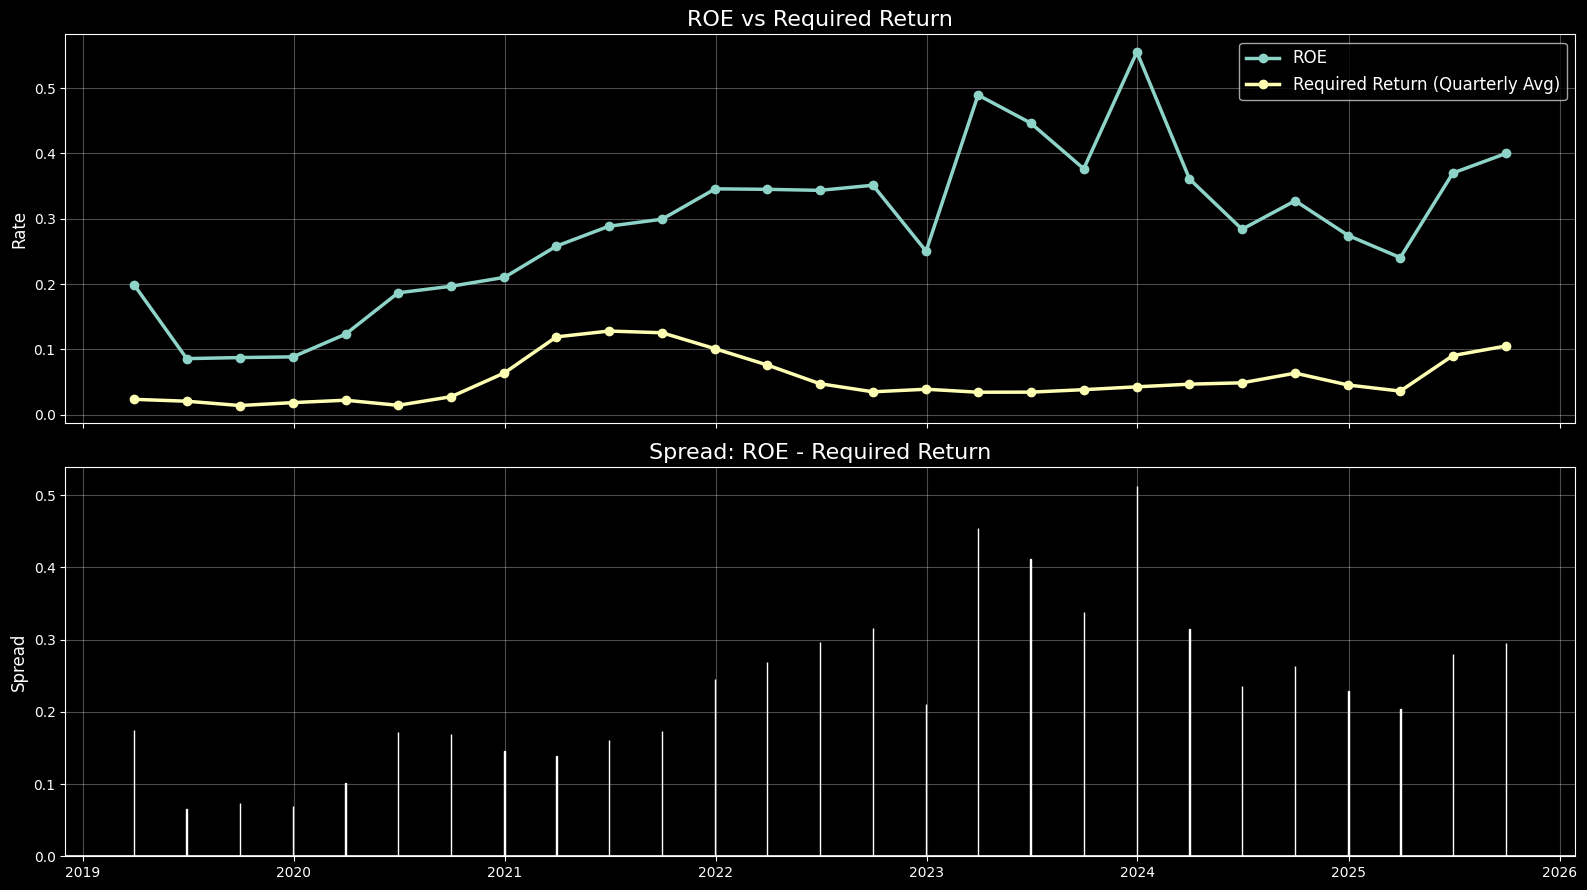

In [219]:
import matplotlib.pyplot as plt

df = ri_raw.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Spread
df['spread'] = df['ROE'] - df['required_return_q_avg']

plt.style.use('dark_background')  # 기존 스타일 유지

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ------------------------------
# (A) 위 차트: 라인 비교
# ------------------------------
ax1.plot(df.index, df['ROE'], marker='o', linewidth=2.5, label='ROE')
ax1.plot(df.index, df['required_return_q_avg'], marker='o', linewidth=2.5,
         label='Required Return (Quarterly Avg)')

ax1.set_title("ROE vs Required Return", fontsize=16)
ax1.set_ylabel("Rate", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

# ------------------------------
# (B) 아래 차트: Spread Bar
# ------------------------------
# ★ 막대를 강한 색으로 변경 (Orange / Blue)
colors = ['#FF9800' if x >= 0 else '#00BCD4' for x in df['spread']]

ax2.bar(df.index, df['spread'], color=colors, edgecolor='white', linewidth=1.0)

ax2.axhline(0, color='white', linewidth=1.2)
ax2.set_title("Spread: ROE - Required Return", fontsize=16)
ax2.set_ylabel("Spread", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [222]:
# 예: 기초 자기자본 (원 단위, 예시 숫자)
B0 = book_value  # 5조원 같은 식으로 입력

# ri_raw에서 마지막 요구수익률 (예: 0.107270)
re_last = float(ri_raw["required_return_q_avg"].iloc[-1])

ri_raw_sorted = ri_raw.sort_values("date")
current_roe = ri_raw_sorted["ROE"].iloc[-1]
longterm_g = roe_mean - re_mean

# 예시 숫자 — 실제 값은 교수님이 입력
B0 = book_value  # SK하이닉스 자기자본 (원) 예시
rr = re_last                # 요구수익률 10% 가정
spread = longterm_g           # (ROE - re) 장기 평균 6%

# 배당금 변수
div_ratio = 0.0

n_high_year = 5
n_fade_year = 15

ri_table, fair_value = residual_income_valuation(
    initial_book_value = B0,
    current_roe = current_roe,
    required_return = re_last,
    payout_ratio = div_ratio,
    n_high_years = n_high_year ,
    n_fade_years = n_fade_year ,
)

print(ri_table)       # 연간 residual income, book value, (roe - re) 확인
print(current_roe)
print("적정 가치 V0:", fair_value)

    year     begin_book       roe  required_return  spread_roe_minus_re  \
0      1    6566.354079  0.400090         0.105182             0.294908   
1      2    9193.487404  0.400090         0.105182             0.294908   
2      3   12871.710791  0.400090         0.105182             0.294908   
3      4   18021.554977  0.400090         0.105182             0.294908   
4      5   25231.800890  0.400090         0.105182             0.294908   
5      6   35326.794882  0.380430         0.105182             0.275248   
6      7   48766.151981  0.360769         0.105182             0.255587   
7      8   66359.468537  0.341108         0.105182             0.235927   
8      9   88995.245030  0.321448         0.105182             0.216266   
9     10  117602.581217  0.301787         0.105182             0.196605   
10    11  153093.554842  0.282127         0.105182             0.176945   
11    12  196285.352836  0.262466         0.105182             0.157284   
12    13  247803.637884  

In [203]:
import os

# ----------------------------------------
# 1) 저장 경로 & 파일명 만들기
# ----------------------------------------
base_path = r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Results\Korea"

# ticker / ROE / 배당성향 / 고성장연수 / 점감연수 포함한 파일명
# 소수점은 너무 길어지지 않게 포맷팅
file_name = (
    f"{ticker}_"
    f"ROE{current_roe:.4f}_"
    f"DIV{div_ratio:.2f}_"
    f"H{n_high_year}_"
    f"F{n_fade_year}.xlsx"
)

# OS에 맞게 경로 합치기
save_path = os.path.join(base_path, file_name)

# 폴더가 없으면 생성 (이미 있으면 무시)
os.makedirs(base_path, exist_ok=True)

# ----------------------------------------
# 2) ri_table 엑셀로 저장
# ----------------------------------------
# ri_table: residual_income_valuation()에서 나온 DataFrame이라고 가정
ri_table.to_excel(save_path, index=False)

print(f"RI 테이블을 다음 경로에 저장했습니다:\n{save_path}")

RI 테이블을 다음 경로에 저장했습니다:
C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Results\Korea\006910_ROE0.1678_DIV0.00_H20_F10.xlsx


In [223]:
ri_df, fair_value = rim_constant_spread_with_payout(
    initial_book_value= B0,
    required_return = rr,
    spread = spread,
    payout_ratio = div_ratio,   # ← 여기 숫자만 바꾸면 됩니다 (5% 배당)
    horizon_years = 20
)

print(spread)
print(fair_value)

0.2342526096707998
306957.8335271767


In [214]:
ri_df, fair_value = rim_constant_spread_with_payout(
    initial_book_value= B0,
    required_return = rr,
    spread = 0.1,
    payout_ratio = div_ratio,   # ← 여기 숫자만 바꾸면 됩니다 (5% 배당)
    horizon_years = 10
)
print(spread_mean)
print(fair_value)

0.0007126881125356428
11238.307595481161


In [215]:
ri_df, fair_value = rim_with_omega(
    initial_book_value= book_value,
    roe = 0.15,
    required_return = rr,
    payout_ratio= div_ratio,
    omega = 0.8,
    horizon_years = 10,
)

print(ri_df.head())
print("적정 가치:", fair_value)

   year   begin_book   roe  required_return  spread_roe_minus_re   net_income  \
0     1  4688.294230  0.15         0.094554             0.055446   703.244135   
1     2  5391.538365  0.15         0.094554             0.055446   808.730755   
2     3  6200.269119  0.15         0.094554             0.055446   930.040368   
3     4  7130.309487  0.15         0.094554             0.055446  1069.546423   
4     5  8199.855910  0.15         0.094554             0.055446  1229.978387   

   dividend  residual_income  omega     next_RI     end_book  discount_factor  \
0       0.0       259.948723    0.8  207.958978  5391.538365         0.913614   
1       0.0       207.958978    0.8  166.367183  6200.269119         0.834691   
2       0.0       166.367183    0.8  133.093746  7130.309487         0.762586   
3       0.0       133.093746    0.8  106.474997  8199.855910         0.696710   
4       0.0       106.474997    0.8   85.179998  9429.834297         0.636524   

   pv_residual_income  
0 

In [216]:
req_q_df

,date,ticker,required_return_q_avg
0,2019-03-31,000500,0.022066
1,2019-06-30,000500,0.019601
2,2019-09-30,000500,0.013959
3,2019-12-31,000500,0.017633
4,2020-03-31,000500,0.019181
5,2020-06-30,000500,0.014297
6,2020-09-30,000500,0.021683
7,2020-12-31,000500,0.043738
8,2021-03-31,000500,0.077395
9,2021-06-30,000500,0.080165


In [122]:
print(yearly_payout)

    year  ticker  payout_ratio_yearly_avg
0   2004  042700                      NaN
1   2005  042700                 0.000000
2   2006  042700                 0.058056
3   2007  042700                 0.062370
4   2008  042700                 0.047172
5   2009  042700                 0.122042
6   2010  042700                 0.064509
7   2011  042700                 0.096151
8   2012  042700                 0.040041
9   2013  042700                 0.107875
10  2014  042700                 0.218609
11  2015  042700                 0.165112
12  2016  042700                 0.093149
13  2017  042700                 0.126638
14  2018  042700                 0.174930
15  2019  042700                 0.079097
16  2020  042700                 0.047783
17  2021  042700                 0.078204
18  2022  042700                 0.071546
19  2023  042700                 0.023650
20  2024  042700                 0.049753
21  2025  042700                 0.165247


In [182]:
import pandas as pd
import pymysql


def get_indicator_pivot(db_info, ticker,
                        table_name="korea_required_return_result"):
    """
    주어진 ticker의 데이터를 MariaDB에서 불러와
    date × indicator 피벗 테이블로 변환하여 반환.

    index: date
    columns: indicator
    values: value
    """

    # DB 연결
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info.get("database", db_info.get("db")),
        charset="utf8mb4",
        cursorclass=pymysql.cursors.DictCursor
    )

    try:
        # SQL: ticker 데이터 불러오기
        sql = f"""
            SELECT date, indicator, value
            FROM {table_name}
            WHERE ticker = %s
            ORDER BY date
        """

        df = pd.read_sql(sql, conn, params=(ticker,), parse_dates=["date"])

    finally:
        conn.close()

    if df.empty:
        print(f"[WARN] 데이터가 없습니다: ticker={ticker}")
        return pd.DataFrame()

    # indicator 웨이트스페이스 제거
    df["indicator"] = df["indicator"].astype(str).str.strip()

    # date NaT 제거
    df = df.dropna(subset=["date", "indicator"])

    # pivot 수행
    pivot_df = df.pivot_table(
        index="date",
        columns="indicator",
        values="value",
        aggfunc="mean"   # 중복 발생 시 평균
    )

    pivot_df = pivot_df.sort_index()

    return pivot_df


In [187]:
tic = "000660"

pivot_df = get_indicator_pivot(db_info, ticker=tic)
print(pivot_df.head())

Empty DataFrame
Columns: []
Index: []


In [217]:
roe_df

,date,ticker,indicator,value
0,2004-03-31,000500,ROE,NaN
1,2004-06-30,000500,ROE,NaN
2,2004-09-30,000500,ROE,NaN
3,2004-12-31,000500,ROE,NaN
4,2005-03-31,000500,ROE,0.066868
...,...,...,...,...
82,2024-09-30,000500,ROE,0.058790
83,2024-12-31,000500,ROE,0.064623
84,2025-03-31,000500,ROE,0.082121
85,2025-06-30,000500,ROE,0.097863
